# 04 — Exploration (Explore & Interpret)

Exploratory data analysis of the 1000-book dataset produced by `03_cleaning.ipynb`.

**Framing**: the cleaning stage established quantitatively that this site's prices and ratings
are randomly generated. This notebook therefore has two goals, and is honest about both:

1. **Apply the full EDA toolkit correctly** — univariate distributions, bivariate relationships,
   categorical comparisons, correlation, outlier detection.
2. **Interpret the results honestly.** Where no relationship exists, that is reported as the
   finding. No pattern is manufactured from noise.

Working with a dataset whose ground truth is known (uniform random) is arguably a *better*
methodological exercise than working with unknown data: every technique can be checked against
what it should produce.

In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../data/processed/books_clean.csv")
print(df.shape)
df.head()

(1000, 8)


,upc,title,category,price,rating,stock,description,detail_url
0,a897fe39b1053632,A Light in the Attic,Poetry,51.77,3,22,It's hard to imagine a world without A Light i...,https://books.toscrape.com/catalogue/a-light-i...
1,90fa61229261140a,Tipping the Velvet,Historical Fiction,53.74,1,20,"""Erotic and absorbing...Written with starling ...",https://books.toscrape.com/catalogue/tipping-t...
2,6957f44c3847a760,Soumission,Fiction,50.10,1,20,"Dans une France assez proche de la nôtre, un h...",https://books.toscrape.com/catalogue/soumissio...
3,e00eb4fd7b871a48,Sharp Objects,Mystery,47.82,4,20,"WICKED above her hipbone, GIRL across her hear...",https://books.toscrape.com/catalogue/sharp-obj...
4,4165285e1663650f,Sapiens: A Brief History of Humankind,History,54.23,5,20,From a renowned historian comes a groundbreaki...,https://books.toscrape.com/catalogue/sapiens-a...


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   upc          1000 non-null   str    
 1   title        1000 non-null   str    
 2   category     1000 non-null   str    
 3   price        1000 non-null   float64
 4   rating       1000 non-null   int64  
 5   stock        1000 non-null   int64  
 6   description  998 non-null    str    
 7   detail_url   1000 non-null   str    
dtypes: float64(1), int64(2), str(5)
memory usage: 62.6 KB


In [4]:
df.describe()

,price,rating,stock
count,1000.00000,1000.000000,1000.000000
mean,35.07035,2.923000,8.585000
std,14.44669,1.434967,5.654622
min,10.00000,1.000000,1.000000
25%,22.10750,2.000000,3.000000
50%,35.98000,3.000000,7.000000
75%,47.45750,4.000000,14.000000
max,59.99000,5.000000,22.000000


## Univariate analysis — one variable at a time

The first question in any EDA is what each variable looks like on its own: its centre, its spread, and its shape. Shape matters most here, because it's what reveals whether the data is naturally occurring or generated.

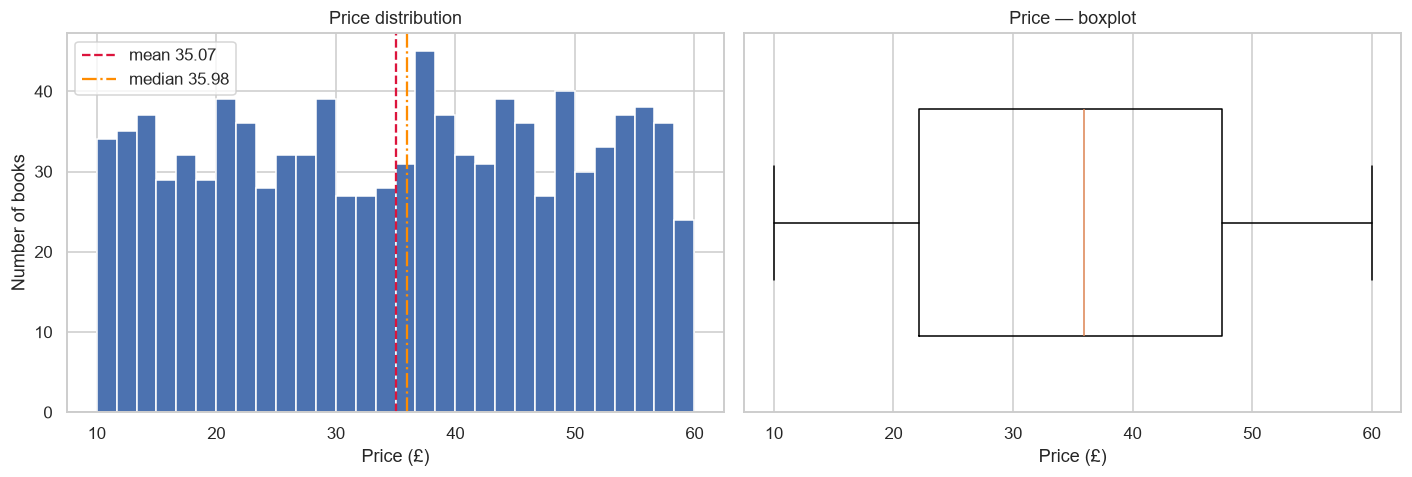

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df["price"], bins=30, edgecolor="white")
axes[0].axvline(df["price"].mean(), color="crimson", linestyle="--", label=f"mean {df['price'].mean():.2f}")
axes[0].axvline(df["price"].median(), color="darkorange", linestyle="-.", label=f"median {df['price'].median():.2f}")
axes[0].set_title("Price distribution")
axes[0].set_xlabel("Price (£)")
axes[0].set_ylabel("Number of books")
axes[0].legend()

axes[1].boxplot(df["price"], orientation="horizontal", widths=0.6)
axes[1].set_title("Price — boxplot")
axes[1].set_xlabel("Price (£)")
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

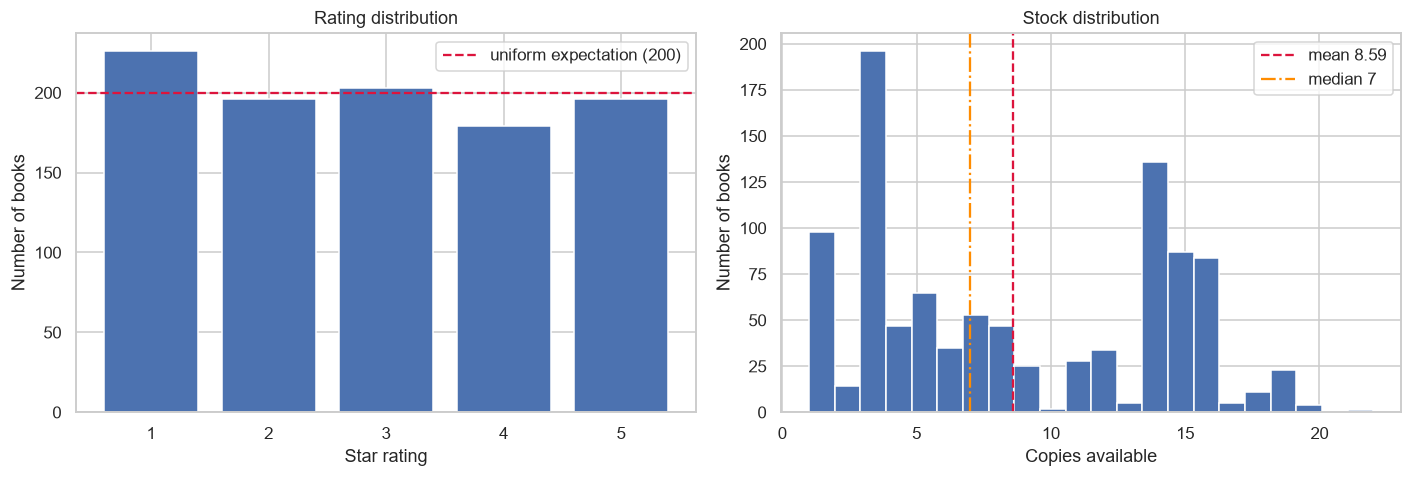

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

rating_counts = df["rating"].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, edgecolor="white")
axes[0].axhline(len(df) / 5, color="crimson", linestyle="--", label="uniform expectation (200)")
axes[0].set_title("Rating distribution")
axes[0].set_xlabel("Star rating")
axes[0].set_ylabel("Number of books")
axes[0].legend()

axes[1].hist(df["stock"], bins=22, edgecolor="white")
axes[1].axvline(df["stock"].mean(), color="crimson", linestyle="--", label=f"mean {df['stock'].mean():.2f}")
axes[1].axvline(df["stock"].median(), color="darkorange", linestyle="-.", label=f"median {df['stock'].median():.0f}")
axes[1].set_title("Stock distribution")
axes[1].set_xlabel("Copies available")
axes[1].set_ylabel("Number of books")
axes[1].legend()

plt.tight_layout()
plt.show()

In [7]:
def shape_stats(name, arr):
    mean, median = np.mean(arr), np.median(arr)
    std = np.std(arr, ddof=1)
    skew = np.mean(((arr - mean) / std) ** 3)
    print(f"{name:8} mean={mean:6.2f}  median={median:6.2f}  std={std:5.2f}  skew={skew:+.3f}")

shape_stats("price", df["price"].to_numpy())
shape_stats("rating", df["rating"].to_numpy())
shape_stats("stock", df["stock"].to_numpy())

price    mean= 35.07  median= 35.98  std=14.45  skew=-0.037
rating   mean=  2.92  median=  3.00  std= 1.43  skew=+0.074
stock    mean=  8.59  median=  7.00  std= 5.65  skew=+0.212


### Univariate findings

**Price — uniform.** The histogram is flat across the entire £10–£59.99 range with no central
peak, mean and median nearly identical (35.07 / 35.98), and skew of −0.037. The boxplot shows
**zero outliers**, with whiskers terminating exactly at the data bounds. Real retail prices are
right-skewed and cluster at psychological price points (£9.99, £14.99); none of that is present.

**Rating — uniform.** All five levels sit close to the 200-book expectation
(226/196/203/179/196). Real book ratings skew heavily toward 4–5 stars; this does not.

**Stock — multimodal, and the most revealing variable.** The skew statistic (+0.212) suggests a
mild right tail, but the histogram tells a different story: a large spike at 3 copies, a sparse
valley around 9–13, and a second cluster at 14–16. This is neither uniform nor naturally
distributed — it suggests stock levels were assigned from a small number of discrete pools
rather than drawn from a single continuous range.

**Methodological note**: stock is a good illustration of why summary statistics are not a
substitute for plotting. Mean, median and skew alone would have characterised it as "slightly
right-skewed" and missed the multimodality entirely — the single most distinctive feature of
the variable.

## Bivariate analysis — relationships between variables

Given that price and rating are both uniformly random, correlations between them should be
approximately zero. This section tests that expectation rather than assuming it.

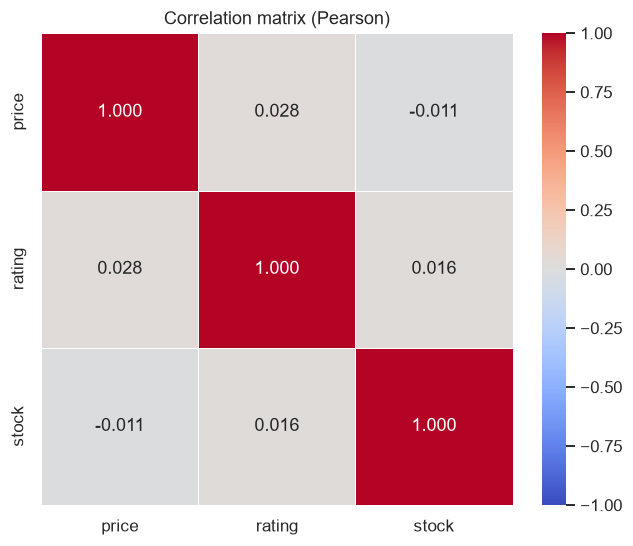

           price    rating     stock
price   1.000000  0.028166 -0.010914
rating  0.028166  1.000000  0.016166
stock  -0.010914  0.016166  1.000000


In [13]:
numeric = df[["price", "rating", "stock"]]
corr = numeric.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation matrix (Pearson)")
plt.tight_layout()
plt.show()

print(corr)

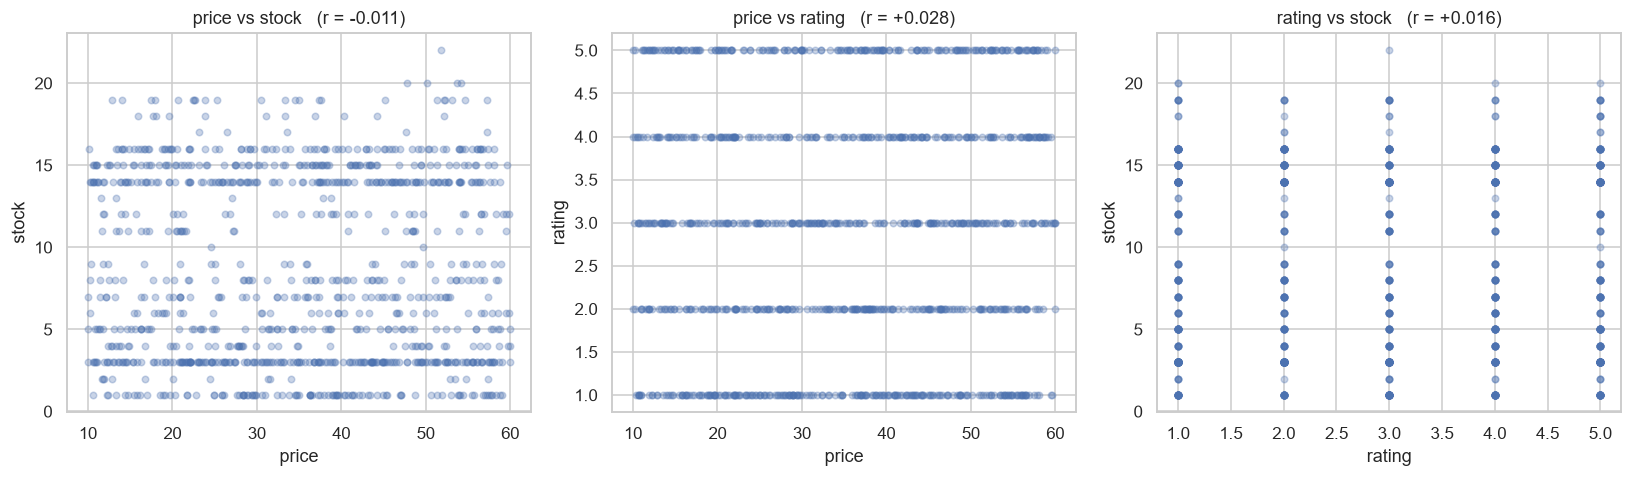

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

pairs = [("price", "stock"), ("price", "rating"), ("rating", "stock")]
for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df[x], df[y], alpha=0.3, s=18)
    r = df[x].corr(df[y])
    ax.set_title(f"{x} vs {y}   (r = {r:+.3f})")
    ax.set_xlabel(x)
    ax.set_ylabel(y)

plt.tight_layout()
plt.show()

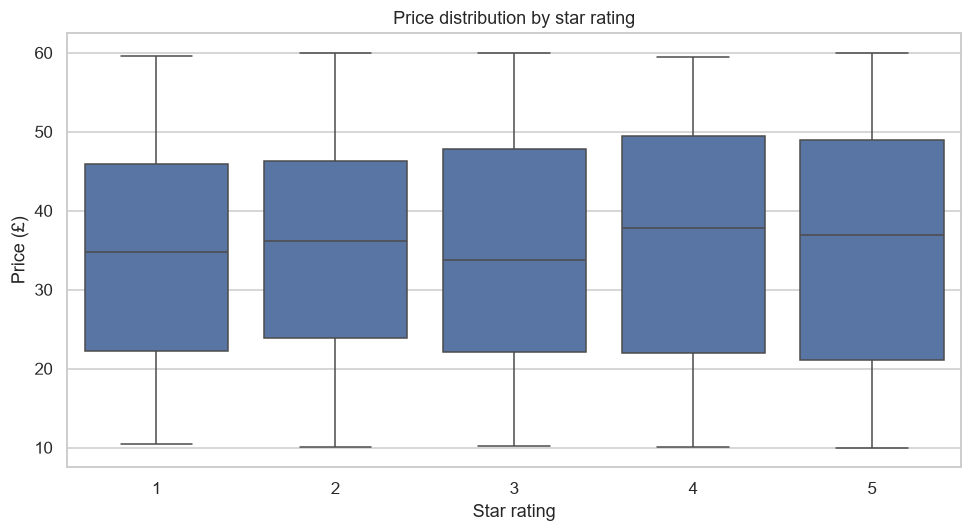

        count   mean  median    std
rating                             
1         226  34.56   34.77  13.95
2         196  34.81   36.22  13.61
3         203  34.69   33.78  14.70
4         179  36.09   37.80  15.08
5         196  35.37   36.90  15.05


In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="rating", y="price", ax=ax)
ax.set_title("Price distribution by star rating")
ax.set_xlabel("Star rating")
ax.set_ylabel("Price (£)")
plt.tight_layout()
plt.show()

print(df.groupby("rating")["price"].agg(["count", "mean", "median", "std"]).round(2))

### Bivariate findings

| Pair | Pearson r | Interpretation |
|---|---|---|
| price ↔ rating | +0.028 | No relationship |
| price ↔ stock | −0.011 | No relationship |
| rating ↔ stock | +0.016 | No relationship |

All three coefficients sit within ±0.03 of zero. As a rule of thumb, |r| below 0.1 is
considered negligible even when statistically detectable; these are an order of magnitude
below that threshold. **There is no linear relationship between any pair of numeric variables
in this dataset.**

This is the expected result, and it functions as a validation of the whole pipeline: variables
generated independently at random *should* produce near-zero correlations. Had a moderate
correlation appeared, it would more likely have indicated a bug in the scraping or parsing
than a genuine discovery.

**Price by rating** confirms the same result in a different form: the five boxes have nearly
identical medians (~34–38) and near-identical spreads, each covering almost the full £10–£60
range. Higher-rated books are not more expensive.

**A note on chart selection**: the price-vs-rating scatter is deliberately included even though
it's a poor visualisation. Plotting a continuous variable against a five-level discrete one
collapses into horizontal lines that reveal nothing about density or overlap. The boxplot is
the correct tool for a continuous/categorical pair, and the contrast between the two makes
that point concretely.

**Limitation of Pearson's r**: it measures *linear* association only. The scatter plots were
checked visually for curved or clustered structure and show none — the point cloud is
uniformly filled, apart from the horizontal banding caused by stock's multimodality.

## Categorical analysis — the 50 categories

Category is the one variable that is *not* randomly generated: it reflects how books were
actually filed on the site. It's therefore the most informative dimension available, and the
place where genuine structure is most likely to appear.

Categories: 50
Largest : {'Default': 152, 'Nonfiction': 110, 'Sequential Art': 75, 'Add a comment': 67, 'Fiction': 65}
Smallest: {'Suspense': 1, 'Academic': 1, 'Adult Fiction': 1, 'Parenting': 1, 'Paranormal': 1}


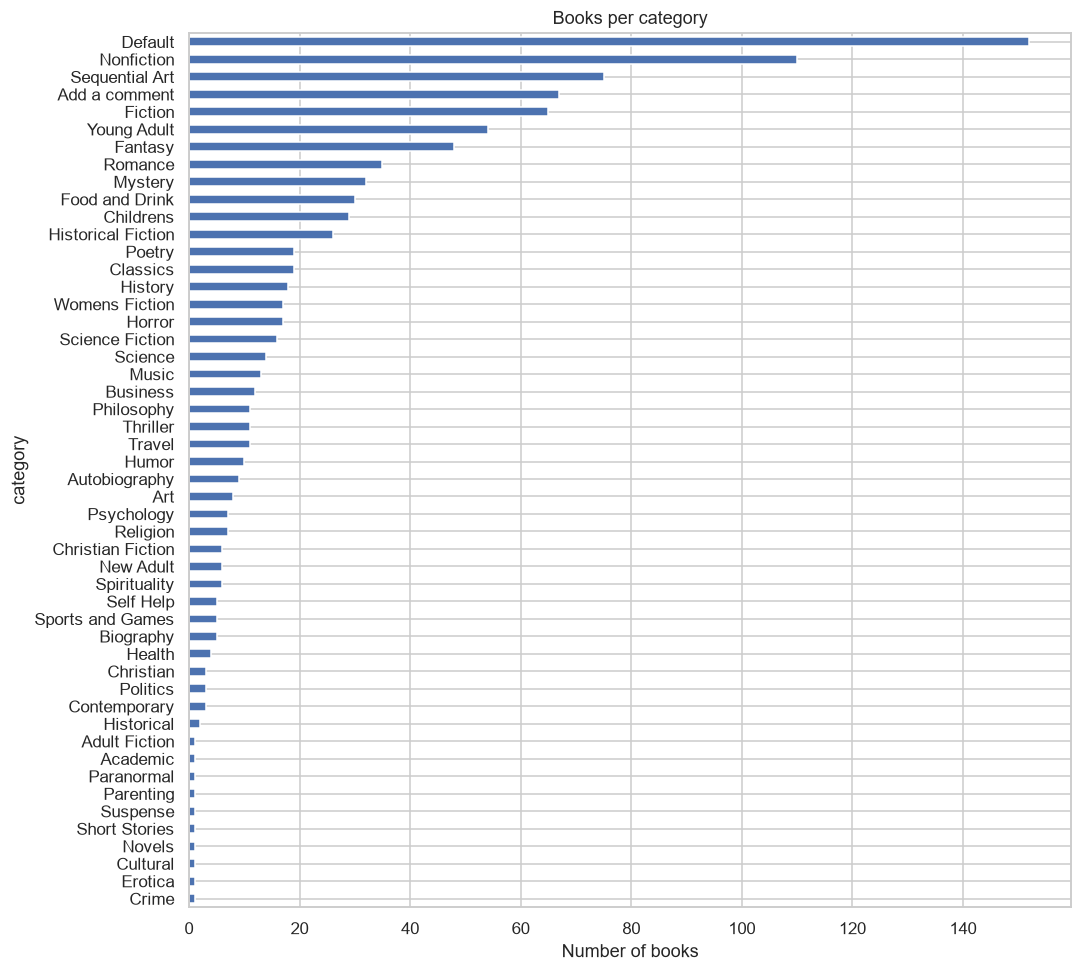

In [15]:
cat_counts = df["category"].value_counts()

print("Categories:", df["category"].nunique())
print("Largest :", cat_counts.head(5).to_dict())
print("Smallest:", cat_counts.tail(5).to_dict())

fig, ax = plt.subplots(figsize=(10, 9))
cat_counts.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Books per category")
ax.set_xlabel("Number of books")
plt.tight_layout()
plt.show()

In [16]:
MIN_BOOKS = 10

cat_stats = (df.groupby("category")
               .agg(n=("price", "size"),
                    mean_price=("price", "mean"),
                    median_price=("price", "median"),
                    mean_rating=("rating", "mean"))
               .round(2)
               .sort_values("mean_price", ascending=False))

big_cats = cat_stats[cat_stats["n"] >= MIN_BOOKS]
print(f"{len(big_cats)} of {len(cat_stats)} categories have >= {MIN_BOOKS} books")
big_cats

25 of 50 categories have >= 10 books


,n,mean_price,median_price,mean_rating
category,,,,
Travel,11,39.79,38.95,2.73
Fantasy,48,39.59,43.58,3.08
History,18,37.29,41.29,2.94
Womens Fiction,17,36.79,43.58,3.12
Classics,19,36.55,35.01,2.47
Fiction,65,36.07,39.72,3.18
Poetry,19,35.97,38.77,3.53
Horror,17,35.95,36.97,2.71
Add a comment,67,35.80,36.17,2.76


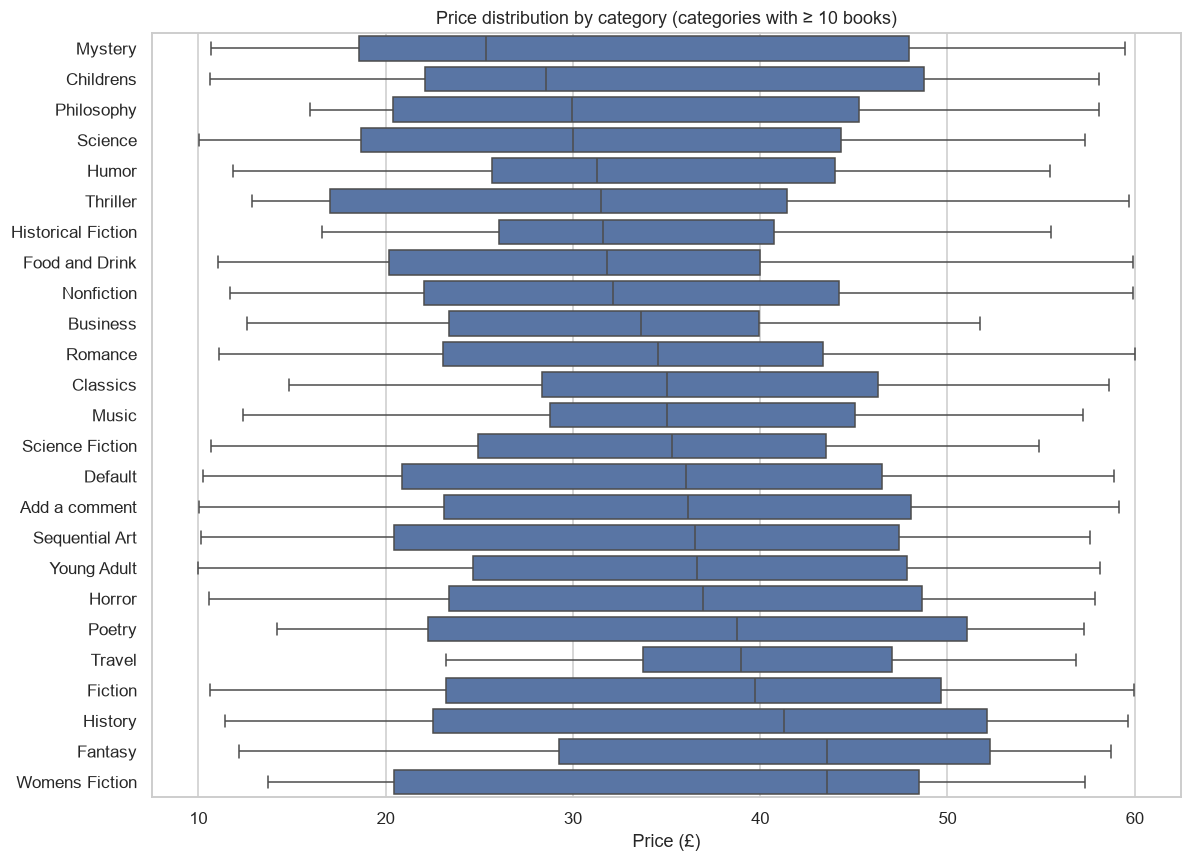

In [17]:
keep = big_cats.index.tolist()
subset = df[df["category"].isin(keep)]

order = subset.groupby("category")["price"].median().sort_values().index

fig, ax = plt.subplots(figsize=(11, 8))
sns.boxplot(data=subset, y="category", x="price", order=order, ax=ax)
ax.set_title(f"Price distribution by category (categories with ≥ {MIN_BOOKS} books)")
ax.set_xlabel("Price (£)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

Observed spread in category mean prices : £8.38
Simulated spread (labels shuffled)      : mean £13.27, 95th pct £18.38
Proportion of random shuffles >= observed: 0.977


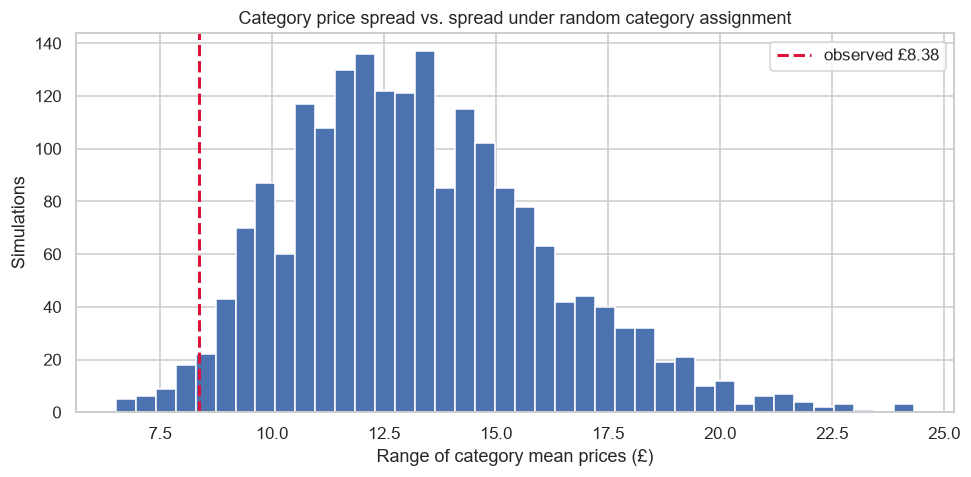

In [18]:
rng = np.random.default_rng(42)

observed_range = big_cats["mean_price"].max() - big_cats["mean_price"].min()

sizes = big_cats["n"].to_numpy()
all_prices = df["price"].to_numpy()

sim_ranges = []
for _ in range(2000):
    shuffled = rng.permutation(all_prices)
    idx, means = 0, []
    for n in sizes:
        means.append(shuffled[idx:idx + n].mean())
        idx += n
    sim_ranges.append(max(means) - min(means))

sim_ranges = np.array(sim_ranges)
p = (sim_ranges >= observed_range).mean()

print(f"Observed spread in category mean prices : £{observed_range:.2f}")
print(f"Simulated spread (labels shuffled)      : mean £{sim_ranges.mean():.2f}, "
      f"95th pct £{np.percentile(sim_ranges, 95):.2f}")
print(f"Proportion of random shuffles >= observed: {p:.3f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(sim_ranges, bins=40, edgecolor="white")
ax.axvline(observed_range, color="crimson", linestyle="--", linewidth=2,
           label=f"observed £{observed_range:.2f}")
ax.set_title("Category price spread vs. spread under random category assignment")
ax.set_xlabel("Range of category mean prices (£)")
ax.set_ylabel("Simulations")
ax.legend()
plt.tight_layout()
plt.show()

### Categorical findings

**The category field contains non-genres.** Two of the four largest categories are not real
genres at all:

| Category | Books | Issue |
|---|---|---|
| `Default` | 152 | Placeholder for unclassified books |
| `Add a comment` | 67 | A UI element captured as a breadcrumb — a site-side data error |

Together these account for **219 books (22% of the dataset)** with no meaningful genre label.
This was not visible during cleaning, where `category` looked healthy: 50 unique values, zero
missing. Only ranking by frequency exposed it. A missing-value check would never have caught
this, because the values are present — they are simply meaningless.

**The distribution is severely long-tailed.** Half the categories (25 of 50) contain fewer than
10 books, and several contain exactly one. Any per-category statistic computed on those is
noise, which is why analysis was restricted to categories with ≥10 books.

**Category mean prices differ — but not more than chance would produce.** Observed spread across
the 25 larger categories is £8.38 (Travel £39.79 down to Food and Drink £31.41). A permutation
test shuffling category labels 2000 times shows this spread falls well within the range produced
by random assignment. **The apparent price differences between genres are sampling noise, not
structure.**

This is the analytically important result of the section: a table of category means *looks* like
a finding, and ranking it makes the differences feel real. Testing it against a null model is
what distinguishes a genuine effect from an artefact of small samples.

In [19]:
print("Observed category mean prices — spread breakdown:")
print(f"  min category mean: £{big_cats['mean_price'].min():.2f} ({big_cats['mean_price'].idxmin()})")
print(f"  max category mean: £{big_cats['mean_price'].max():.2f} ({big_cats['mean_price'].idxmax()})")
print(f"  std of category means: £{big_cats['mean_price'].std():.2f}")
print(f"  global price mean: £{df['price'].mean():.2f}")
print()
print(f"Percentile of observed spread in simulated distribution: "
      f"{(sim_ranges < observed_range).mean() * 100:.1f}%")

Observed category mean prices — spread breakdown:
  min category mean: £31.41 (Food and Drink)
  max category mean: £39.79 (Travel)
  std of category means: £2.23
  global price mean: £35.07

Percentile of observed spread in simulated distribution: 2.3%


### Permutation test result

| Quantity | Value |
|---|---|
| Observed spread in category mean prices | £8.38 |
| Mean spread under shuffled labels | £13.27 |
| 95th percentile under shuffled labels | £18.38 |
| Proportion of shuffles ≥ observed | **0.977** |

The observed spread is not merely within the range of chance — it sits in the **far left tail**,
smaller than 97.7% of randomly shuffled arrangements.

**Primary conclusion**: there is no evidence that book category influences price. Had genres
carried real pricing structure, the observed spread would sit in the *right* tail, exceeding
what random assignment produces. It does the opposite.

**Secondary observation**: category means are more tightly clustered around the global mean
(£35.07) than random assignment typically produces. This is noted as an anomaly rather than
explained away — a fuller investigation would need to model the interaction between category
size and the range statistic, since the range is dominated by the smallest categories, and
those are the ones where random draws produce the widest swings.

**Why this test matters**: the category means table looked like a result. Travel books averaging
£8 more than Food and Drink books reads as a finding, especially once sorted. The permutation
test shows it is not. Sorting any set of random group means always produces an apparent ranking —
the ordering is guaranteed by the sort, not by the data.

## Outlier detection

Two standard approaches applied to the numeric variables: the IQR rule (used by boxplots) and
the z-score rule.

In [20]:
def iqr_outliers(series):
    q1, q3 = np.percentile(series, [25, 75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (series < low) | (series > high)
    return mask, low, high

def zscore_outliers(series, threshold=3.0):
    z = (series - series.mean()) / series.std(ddof=1)
    return z.abs() > threshold

for col in ["price", "rating", "stock"]:
    s = df[col]
    iqr_mask, low, high = iqr_outliers(s)
    z_mask = zscore_outliers(s)
    print(f"{col}")
    print(f"  IQR bounds     : {low:.2f} → {high:.2f}   outliers: {iqr_mask.sum()}")
    print(f"  z-score (|z|>3): outliers: {z_mask.sum()}")
    print(f"  actual range   : {s.min():.2f} → {s.max():.2f}")
    print()

price
  IQR bounds     : -15.92 → 85.48   outliers: 0
  z-score (|z|>3): outliers: 0
  actual range   : 10.00 → 59.99

rating
  IQR bounds     : -1.00 → 7.00   outliers: 0
  z-score (|z|>3): outliers: 0
  actual range   : 1.00 → 5.00

stock
  IQR bounds     : -13.50 → 30.50   outliers: 0
  z-score (|z|>3): outliers: 0
  actual range   : 1.00 → 22.00



### Outlier findings

| Variable | IQR fences | Actual range | IQR outliers | z-score outliers |
|---|---|---|---|---|
| price | −15.92 → 85.48 | 10.00 → 59.99 | 0 | 0 |
| rating | −1.00 → 7.00 | 1.00 → 5.00 | 0 | 0 |
| stock | −13.50 → 30.50 | 1.00 → 22.00 | 0 | 0 |

**Zero outliers by either method, on every variable.** The interesting part is why.

Note where the fences fall: the IQR rule places price bounds at −£15.92 and £85.48, while the
data only spans £10.00 to £59.99. The fences sit entirely outside the data. The same holds for
rating (fences at −1 and 7, on a 1–5 scale) and stock. Both methods produce negative lower
bounds for quantities that cannot be negative.

**Why this happens**: both rules are built for distributions with tails. The 1.5×IQR fence is
calibrated so that a normal distribution yields roughly 0.7% outliers; the |z|>3 rule assumes
values thin out as they move from the mean. A uniform distribution has no tails at all — density
is constant right up to a hard boundary, then stops. Its IQR is narrow relative to its full
range, so fences extend past the data, and its standard deviation is large relative to its span,
so nothing reaches 3σ.

**The methodological point**: "zero outliers" here does not mean the data is exceptionally clean.
It means the detection method assumes a shape this data does not have. The correct response to
zero outliers is to check the distribution before concluding anything — and in this case the
histograms from the univariate section already told us to expect exactly this result.

The genuinely anomalous features of this dataset are not extreme values at all. They are the
219 books filed under non-genre categories, and stock's multimodal clustering — neither of which
any outlier rule would flag.

## Conclusions

### What the analysis established

**1. The numeric data is synthetic, and multiple independent lines of evidence confirm it.**

| Evidence | Finding |
|---|---|
| Price distribution | Flat across £10–£59.99, skew −0.037, hard bounds |
| Rating distribution | Near-uniform across 1–5 (226/196/203/179/196) |
| Correlations | All three pairs within ±0.03 of zero |
| Category effect | Permutation test: p = 0.977, no genre pricing structure |
| Outliers | Zero by both IQR and z-score — no tails to have outliers in |

Every result is consistent with independently generated random values, matching the site's own
statement that its prices and ratings are placeholder data.

**2. The most valuable findings came from the categorical variable, not the numeric ones.**

- 22% of books (219) sit in non-genre categories — `Default` (152) and `Add a comment` (67),
  the latter a UI element captured as a breadcrumb. Invisible to missing-value checks, since
  the values are present but meaningless.
- The category distribution is severely long-tailed: 25 of 50 categories hold under 10 books.

**3. Stock is the only numeric variable with real structure** — multimodal, with clusters at 3
and 14–16 and a sparse band around 9–13. Its summary statistics (skew +0.212) actively
mischaracterise it; only the histogram reveals the shape.

### Methodological conclusions

Working with data of known random origin turned this into a test of the methods themselves,
and three lessons emerged that generalise beyond this dataset:

- **Summary statistics are not a substitute for plots.** Stock's skew of +0.212 reads as "mildly
  right-skewed" and completely misses its multimodality.
- **A ranked table of group means always looks like a finding.** Sorting guarantees an apparent
  ordering. The permutation test was what distinguished noise from structure — and it showed the
  £8.38 spread between category means to be well within, in fact below, what chance produces.
- **Outlier detection encodes distributional assumptions.** Zero outliers meant the method didn't
  fit the data, not that the data was clean.

### Limitations

- Prices, ratings and stock are generated, so no conclusion here transfers to the real book market.
- Category is the only field reflecting genuine editorial decisions, and 22% of it is unusable.
- Descriptions were collected but not analysed; text analysis (length, sentiment, keyword
  extraction) is the obvious next step and would use the one field carrying real human-written content.
- The permutation test's left-tail result is reported but not fully explained — the interaction
  between category size and the range statistic warrants a more careful null model.